# Quantum Pattern Generation — FRQI
In the first challenge, Quantum Image Lab: The FRQI Challenge, you were introduced to the FRQI encoding of an image into a quantum state.

It is now time to deep dive into the transformation and generation of quantum visuals using the FRQI encoding.
You will be given target patterns and tasked to build a FRQI circuit that can reproduce them.

### Challenge Outline
1. **Random Noise**

2. **Quantum Checkerboard**

3. **Horizontal and vertical lines**

4. **Nested Squares**

5. **Grayscale Nested Squares**

6. **Quantum Fractals** *(bonus)*


In [115]:
import math
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import utils_images as img_utils
import utils_quantum as q_utils
import importlib
importlib.reload(img_utils)

<module 'utils_images' from '/Users/bren/Desktop/Phys 622 Quantum Computing Essentials/Hackathon/notebooks/iqucodefest-2026-main/side_quests/challenge_02_generative_quantum_art/utils_images.py'>

In [116]:
def _apply_x_mask(qc: QuantumCircuit, address_bitstring: str, position_qubits: list[int]):
    """
    Apply an X-mask to emulate controls-on-0 for an address.

    Args:
    - qc: QuantumCircuit to modify.
    - address_bitstring: "natural" binary string (MSB on the left), e.g. "0101".
    - position_qubits: ordered list of position-qubit indices (q0 = LSB).
      Note: if position_qubits == [0, 1, 2, ...], then position_qubits[i] == i.
    """
    # Reverse so index 0 aligns with q0 (LSB)
    for bit_idx, bit in enumerate(reversed(address_bitstring)):
        if bit == "0":
            qc.x(position_qubits[bit_idx])

def encode_frqi_simple(binary_image: np.ndarray) -> tuple[QuantumCircuit, int]:
    """
    FRQI encoder for a binary (black/white) image.

    Convention used here:
    - Pixel index i is converted to a "natural" bitstring (MSB on the left) with format(...).
    - position qubits are q0..q(k-1), where q0 is the LSB.
    - The helper _apply_x_mask(...) reverses the bitstring to align bits with q0..

    Steps:
    1) Put all positions in superposition (H on all position qubits).
    2) For each black pixel address, apply an X-mask + MCX + undo the mask.
    """
    flat = np.array(binary_image).astype(int).flatten() # flatten to 1D array row-major order: row0, row1, ...
    n_pixels = len(flat)
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels)) # number of position qubits
    n_total = n_pos + 1                    # +1 color qubit
    pos_qubits = list(range(n_pos))        # q0..q(k-1)
    color_qubit = n_pos                    # qk

    # Warn if there are more addresses than pixels
    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")
    
    # Create circuit
    qc = QuantumCircuit(n_total)

    # Step 1) Superposition over addresses
    qc.h(pos_qubits)

    # Step 2) Encode black pixels with MCX
    for i, pixel_val in enumerate(flat):
        if int(pixel_val) != 1:         # only encode black pixels (value 1)
            continue

        address_bitstring = format(i, f"0{n_pos}b")  # MSB..LSB (natural)

        _apply_x_mask(qc, address_bitstring, pos_qubits) # apply X-mask for controls-on-0
        qc.mcx(pos_qubits, color_qubit)                  # Multi-controlled X: flip color qubit when ALL position qubits are |1⟩
        _apply_x_mask(qc, address_bitstring, pos_qubits)  # undo (X is its own inverse)

        qc.barrier() # barrier for visual clarity

        # Note: MCX can apply the sandwiching X gates automatically with the ctrl_state option,

    print(f" FRQI circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")
    
    return qc, n_pos # return circuit and number of position qubits

# TODO : FRQI encoder for grayscale image
def encode_frqi_grayscale(grayscale_image: np.ndarray) -> tuple[QuantumCircuit, int]:
    """
    FRQI encoder for a grayscale image.

    Pixel values are interpreted as darkness intensities:
    - 0   -> white  -> P(color=1) = 0
    - 255 -> black  -> P(color=1) = 1

    For each pixel intensity I in [0, 1], we choose theta so that
    sin(theta)^2 = I, then apply a controlled RY(2*theta).
    """
    flat = np.asarray(grayscale_image, dtype=float).flatten()
    n_pixels = len(flat)
    if n_pixels == 0:
        raise ValueError("Empty image.")

    n_pos = math.ceil(math.log2(n_pixels))
    n_total = n_pos + 1
    pos_qubits = list(range(n_pos))
    color_qubit = n_pos

    if np.max(flat) > 1:
        flat = flat / 255.0
    flat = np.clip(flat, 0.0, 1.0)

    if 2**n_pos > n_pixels:
        print(f"Note: 2^k = {2**n_pos} > N = {n_pixels} (extra addresses stay white)")

    qc = QuantumCircuit(n_total)
    qc.h(pos_qubits)

    for i, intensity in enumerate(flat):
        if intensity == 0:
            continue

        address_bitstring = format(i, f"0{n_pos}b")
        theta = np.arcsin(np.sqrt(intensity))

        _apply_x_mask(qc, address_bitstring, pos_qubits)
        qc.mcry(2 * theta, pos_qubits, color_qubit)
        _apply_x_mask(qc, address_bitstring, pos_qubits)

    print(" FRQI grayscale circuit created!")
    print(f"   Depth: {qc.depth()}, Size: {qc.size()} gates")

    return qc, n_pos


def reconstruct_from_frqi(counts, n_position_qubits, image_shape):
    """
    Reconstruct image from FRQI measurement counts using the 'Ratio' method.
    Args:
    - counts: dict from measurement outcomes to counts.
    - n_position_qubits: number of position qubits used in FRQI.
    - image_shape: tuple (height, width) of the original image.
    
    Returns:
    - reconstructed_image: 2D numpy array of the reconstructed image.
    """
    
    n_pixels = image_shape[0] * image_shape[1] # Total number of pixels
    
    # 1. Accumulate statistics per pixel (Address)
    total_counts = np.zeros(n_pixels, dtype=int)
    ones_counts = np.zeros(n_pixels, dtype=int)
    
    print("Reconstructing image from measurements...\n")
    
    # For each measurement outcome (e.g., '10101')
    for outcome, count in counts.items():
        # Remove spaces if any
        outcome = outcome.replace(" ", "")
        
        # --- VISUAL MAPPING (Left -> High Index) ---
        # The string typically looks like: "C P3 P2 P1 P0"
        # Leftmost character is the Color Qubit
        color_char = outcome[0] 
        
        # The rest is the Position (binary string)
        position_string = outcome[1:]
        
        # Convert "1101" -> 13 (Standard binary: Left is MSB)
        position_idx = int(position_string, 2)
        
        # Only process valid pixel positions
        if position_idx < n_pixels:
            # Accumulate counts for this address
            total_counts[position_idx] += count
            
            # If color bit is 1, count it as a "black" measurement
            if int(color_char) == 1:
                ones_counts[position_idx] += count
    
    # 2. Compute Pixel Values based on Ratio
    reconstructed = np.zeros(n_pixels, dtype=int)
    
    for i in range(n_pixels):
        if total_counts[i] > 0:
            # Calculate proportion of 1s (Intensity)
            ratio = ones_counts[i] / total_counts[i]
            
            # For Binary: Threshold at 50%
            if ratio > 0.5:
                reconstructed[i] = 1
    
    # Reshape to original image dimensions
    reconstructed_image = reconstructed.reshape(image_shape) # from 1D to 2D, row-major order
    
    return reconstructed_image


def reconstruct_grayscale_from_frqi(counts: dict, n_position_qubits: int, image_shape: tuple[int, int]) -> np.ndarray:
    """
    Reconstruct a grayscale image from FRQI measurement counts.

    For each position address, estimate P(color=1) by the ratio:
        color-one counts for that address / total counts for that address.
    Then scale that normalized intensity back to [0, 255].
    """
    n_pixels = image_shape[0] * image_shape[1]
    total_counts = np.zeros(n_pixels, dtype=int)
    ones_counts = np.zeros(n_pixels, dtype=int)

    for outcome, count in counts.items():
        outcome = outcome.replace(" ", "")
        color_bit = int(outcome[0])
        position_idx = int(outcome[1:], 2)

        if position_idx >= n_pixels:
            continue

        total_counts[position_idx] += count
        if color_bit == 1:
            ones_counts[position_idx] += count

    reconstructed = np.zeros(n_pixels, dtype=float)
    nonzero = total_counts > 0
    reconstructed[nonzero] = ones_counts[nonzero] / total_counts[nonzero]

    return np.rint(reconstructed.reshape(image_shape) * 255).astype(np.uint8)



In [117]:
# Create a 16x16 grayscale image
white_16x16 = np.zeros((16, 16), dtype=np.uint8)

## Pattern 1 - Random Noise
You must produce a fully random image, like TV static. Each pixel is drawn independently from the others, with a 50% chance of being black and a 50% chance of being white. Here are 4 examples of what we're looking for:

![random_pattern.png](images/random_noise.png)

 FRQI circuit created!
   Depth: 1, Size: 8 gates
Reconstructing image from measurements...


Reconstructed image:
[[0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1]
 [0 1 1 0 0 1 0 1 1 0 1 0 1 0 0 1]
 [0 0 0 1 0 0 1 0 0 0 1 1 0 1 1 0]
 [1 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0]
 [0 0 0 1 0 1 0 1 1 0 1 1 1 0 1 0]
 [1 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0]
 [1 0 1 1 1 0 0 1 1 1 0 0 0 1 0 0]
 [0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 0]
 [0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 0]
 [0 0 0 1 0 1 0 0 0 1 0 1 1 0 0 0]
 [0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 1]
 [0 1 0 0 1 1 1 0 0 1 1 1 0 0 0 1]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1]
 [1 1 1 0 0 0 1 0 1 0 1 1 1 1 1 0]
 [1 1 1 0 0 0 0 0 0 1 0 1 1 1 1 1]
 [0 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0]]


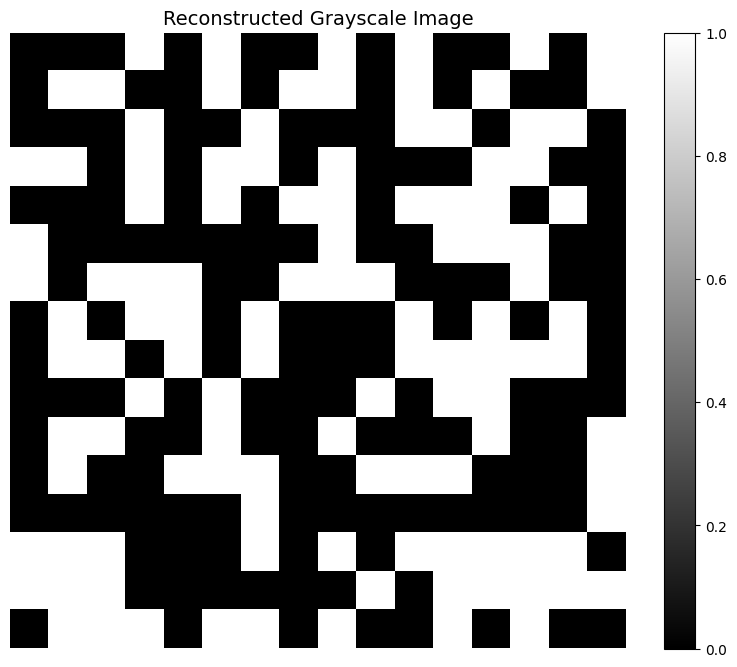

In [118]:
# todo 
# Build FRQI circuit
frqi_circuit, n_pos = encode_frqi_simple(white_16x16)


# Apply hadamard to colour qubit to create superposition of color states (for grayscale encoding)
frqi_circuit.h(n_pos)


# very important: add measurement to the circuit
frqi_circuit.measure_all()



# Note: Since FRQI is probabilistic, we need enough shots 
# to ensure every pixel address is measured at least a few times.
# Heuristic: shots > 50 * n_pixels
num_shots = 100*(2**n_pos) # 200 shots per pixel address
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

# Reconstruct
frqi_reconstructed = reconstruct_from_frqi(counts, n_pos, white_16x16.shape)

print(f"\n{'='*60}")
print("Reconstructed image:")
print(frqi_reconstructed)

img_utils.display_image(frqi_reconstructed, "Reconstructed Grayscale Image")


## Pattern 2 - Quantum Checkerboard

Create a classic checkerboard pattern, that is, alternating black and white pixels. The circuit is **deterministic**: it always produces the same checkerboard.

Can you also figure out how to obtain the negative from this first circuit?

![chess](images/chess.png)

Note: the checkerboard and its negative are reconstructed separately, using distinct circuits.

 FRQI circuit created!
   Depth: 1, Size: 8 gates
Reconstructing image from measurements...


Checkerboard:
[[0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]]


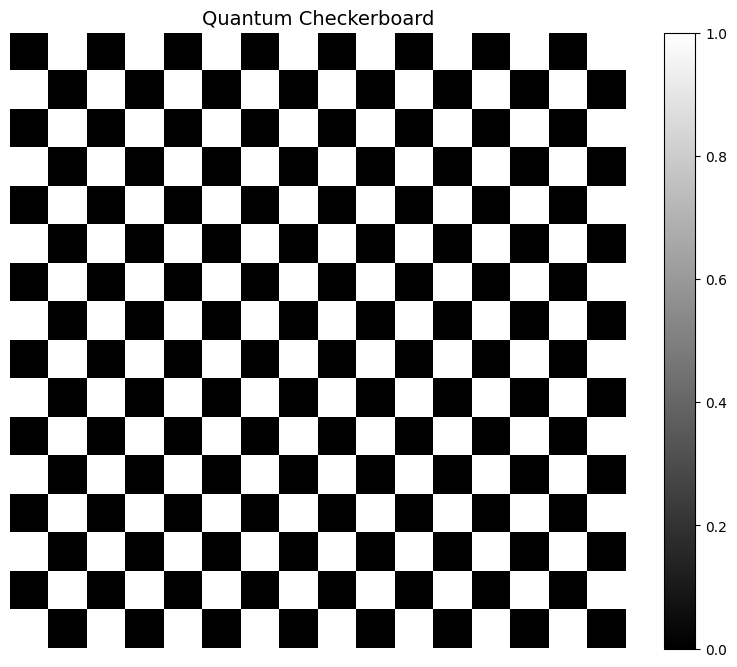

In [119]:
# Build from an all-black image
black_16x16 = np.zeros_like(white_16x16)

frqi_circuit, n_pos = encode_frqi_simple(black_16x16)

height, width = black_16x16.shape
n_col_bits = int(np.log2(width))

# Least significant column bit
col_lsb = 0

# Least significant row bit
row_lsb = n_col_bits




# Checkerboard rule: color = column parity XOR row parity
frqi_circuit.cx(col_lsb, n_pos)
frqi_circuit.cx(row_lsb, n_pos)

frqi_circuit.measure_all()

num_shots = 200 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

frqi_reconstructed = reconstruct_from_frqi(
    counts,
    n_pos,
    black_16x16.shape
)

print(f"\n{'='*60}")
print("Checkerboard:")
print(frqi_reconstructed)

img_utils.display_image(frqi_reconstructed, "Quantum Checkerboard")

 FRQI circuit created!
   Depth: 1, Size: 8 gates
Reconstructing image from measurements...


Checkerboard:
[[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]]


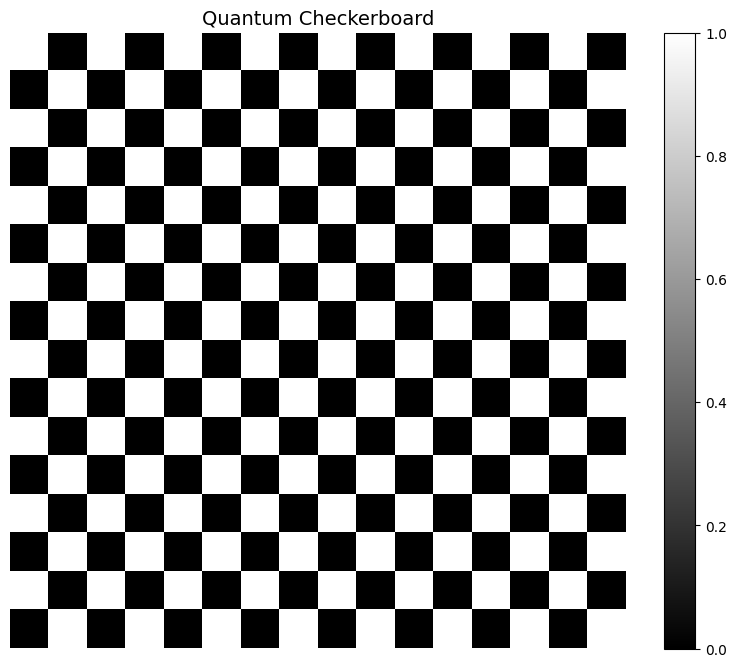

In [120]:
## Flip the checkerboard colors by adding an X gate to the color qubit before measurement


# Build from an all-black image
black_16x16 = np.zeros_like(white_16x16)

frqi_circuit, n_pos = encode_frqi_simple(black_16x16)


height, width = black_16x16.shape
n_col_bits = int(np.log2(width))

# Least significant column bit
col_lsb = 0

# Least significant row bit
row_lsb = n_col_bits

frqi_circuit.x(n_pos)


# Checkerboard rule: color = column parity XOR row parity
frqi_circuit.cx(col_lsb, n_pos)
frqi_circuit.cx(row_lsb, n_pos)

frqi_circuit.measure_all()

num_shots = 200 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

frqi_reconstructed = reconstruct_from_frqi(
    counts,
    n_pos,
    black_16x16.shape
)

print(f"\n{'='*60}")
print("Checkerboard:")
print(frqi_reconstructed)

img_utils.display_image(frqi_reconstructed, "Quantum Checkerboard")


## Pattern 3 - Horizontal Lines
You must generate alternating black and white horizontal lines that remain the same between each run.

![Horizontal lines](images/frqi_bar_horiz.png)

 FRQI circuit created!
   Depth: 1, Size: 8 gates
Reconstructing image from measurements...



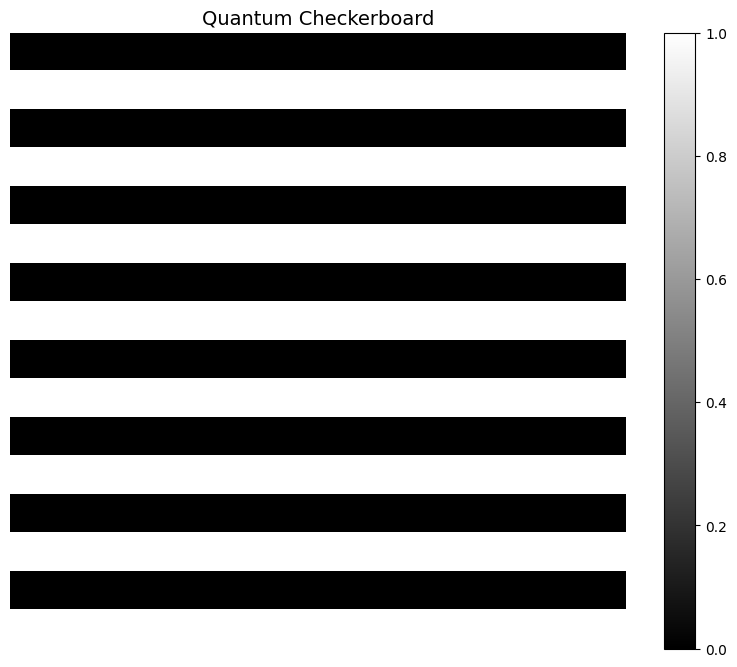

In [121]:
# Build from an all-black image
black_16x16 = np.zeros_like(white_16x16)

# create FRQI circuit for the all-black image
frqi_circuit, n_pos = encode_frqi_simple(black_16x16)

# Get the image dimensions
height, width = black_16x16.shape

# Calculate the number of bits needed for the column index
n_col_bits = int(np.log2(width))

# Least significant column bit
col_lsb = 0

# Least significant row bit
row_lsb = n_col_bits

# cnot based on row parity
frqi_circuit.cx(row_lsb, n_pos)

frqi_circuit.measure_all()

num_shots = 200 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

frqi_reconstructed = reconstruct_from_frqi(
    counts,
    n_pos,
    black_16x16.shape
)

img_utils.display_image(frqi_reconstructed, "Quantum Checkerboard")

## Pattern 4 - Vertical Lines
Same idea as pattern 3, but the lines must be vertical just like in the picture below.

![Vertical lines](images/frqi_bar_ver.png)

 FRQI circuit created!
   Depth: 1, Size: 8 gates
Reconstructing image from measurements...



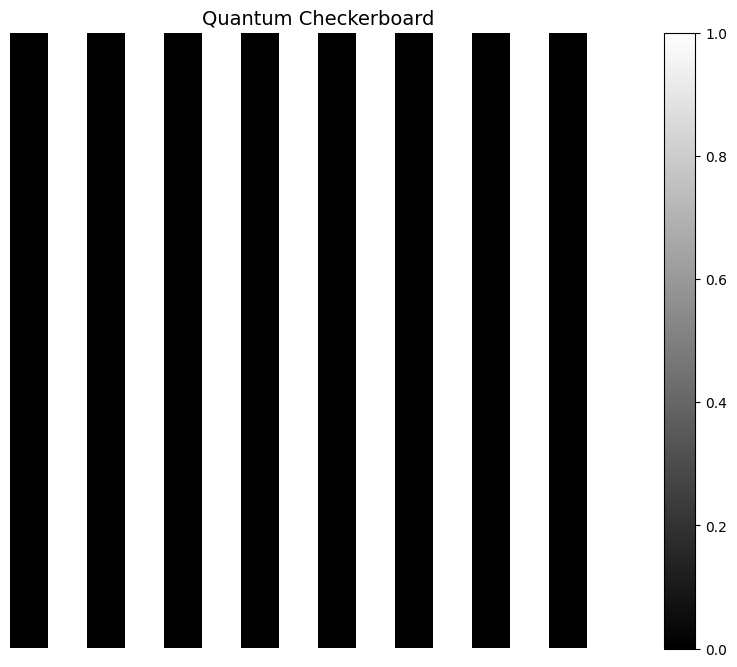

In [122]:
# Build from an all-black image
black_16x16 = np.zeros_like(white_16x16)

# create FRQI circuit for the all-black image
frqi_circuit, n_pos = encode_frqi_simple(black_16x16)

# Get the image dimensions
height, width = black_16x16.shape

# Calculate the number of bits needed for the column index
n_col_bits = int(np.log2(width))

# Least significant column bit
col_lsb = 0

# Least significant row bit
row_lsb = n_col_bits

# cnot based on column parity
frqi_circuit.cx(col_lsb, n_pos)

# Measure the circuit
frqi_circuit.measure_all()

# Create statitics for reconstruction
num_shots = 200 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

frqi_reconstructed = reconstruct_from_frqi(
    counts,
    n_pos,
    black_16x16.shape
)

img_utils.display_image(frqi_reconstructed, "Quantum Checkerboard")

## Pattern 5 - Nested Squares

Here, we want to build concentric rectangles, that is, nested squares that alternate black and white from the outside toward the center. In contrast to the checkerboard and the stripes patterns, each pixel must be handled individually.

To describe this pattern, we consider an image of size $R \times C$:
- $R$ = number of rows
- $C$ = number of columns

For a pixel located at row $r$ and column $c$, we define its **layer** $L(r,c)$ as its distance to the nearest border:

$$
L(r,c) = \min(r, c, R-1-r, C-1-c)
$$

Thus:
- layer $0$ corresponds to the outer border,
- layer $1$ to the first inner rectangle,
- layer $2$ to the next one,
- and so on until the center.

**Your goal:** find an FRQI circuit that reproduces this pattern while respecting the black/white alternation.

![Concentric rectangles](images/frqi_carre.png)

 FRQI circuit created!
   Depth: 119, Size: 286 gates
Reconstructing image from measurements...



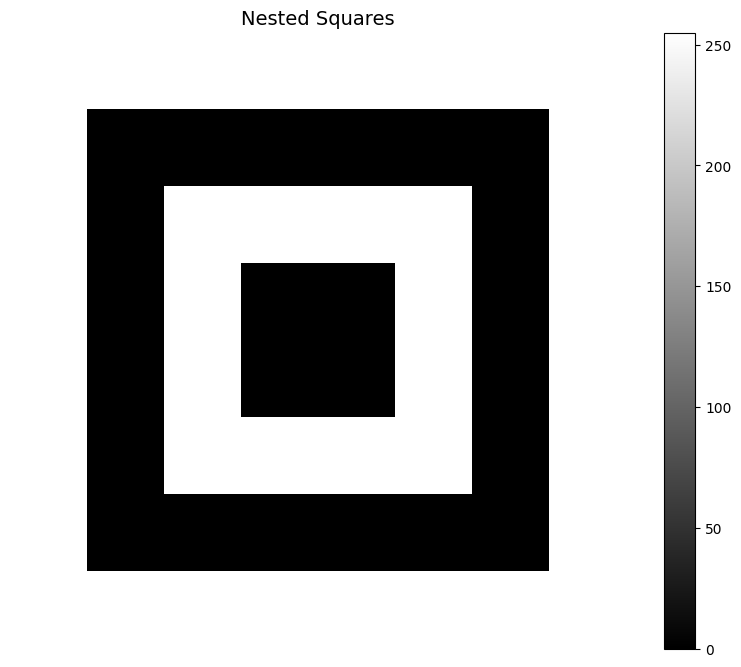

In [123]:
R, C = 8, 8
nested_squares = np.array([
    [1 if min(y, x, R-1-y, C-1-x) % 2 == 0 else 0 for x in range(C)]
    for y in range(R)
])

frqi_circuit, n_pos = encode_frqi_simple(nested_squares)
frqi_circuit.measure_all()

num_shots = 50 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)
reconstructed = reconstruct_from_frqi(counts, n_pos, nested_squares.shape)
img_utils.display_image(reconstructed * 255, "Nested Squares")

## Pattern 6 - Grayscale Nested Squares

Same idea as the Nested Squares in pattern 5, but **each layer has a different intensity**.
You can find how to handle grayscale images using FRQI encoding in challenge 1 Image Lab.

![Grayscale rectangles](images/frqi_carre_gris.png)

Target grayscale nested squares:
[[255 255 255 255 255 255 255 255]
 [255 170 170 170 170 170 170 255]
 [255 170  85  85  85  85 170 255]
 [255 170  85   0   0  85 170 255]
 [255 170  85   0   0  85 170 255]
 [255 170  85  85  85  85 170 255]
 [255 170 170 170 170 170 170 255]
 [255 255 255 255 255 255 255 255]]


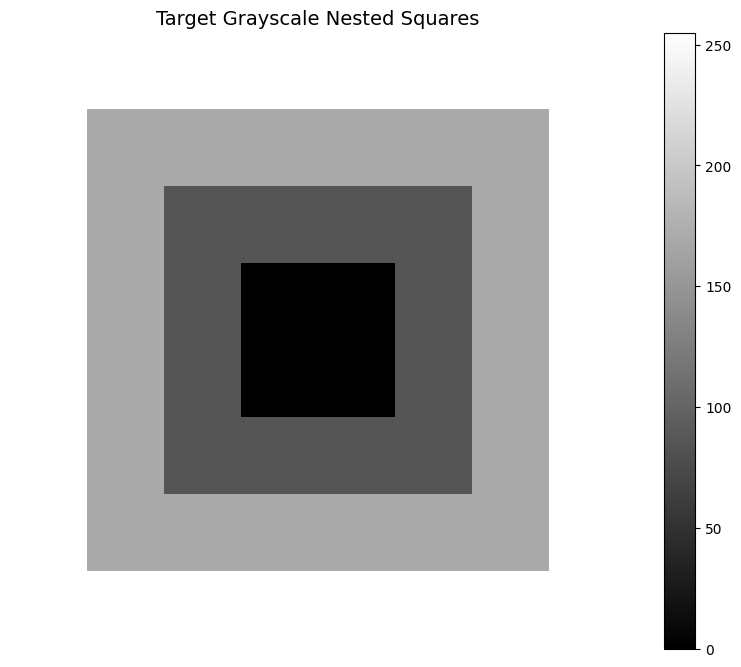

 FRQI grayscale circuit created!
   Depth: 4571, Size: 8046 gates

Reconstructed grayscale nested squares:
[[255 255 255 255 255 255 255 255]
 [255 178 169 159 183 171 163 255]
 [255 170  79  85  79  89 166 255]
 [255 170  84   0   0  86 168 255]
 [255 166  79   0   0  87 170 255]
 [255 168  91  79  86  89 170 255]
 [255 174 178 169 164 170 166 255]
 [255 255 255 255 255 255 255 255]]


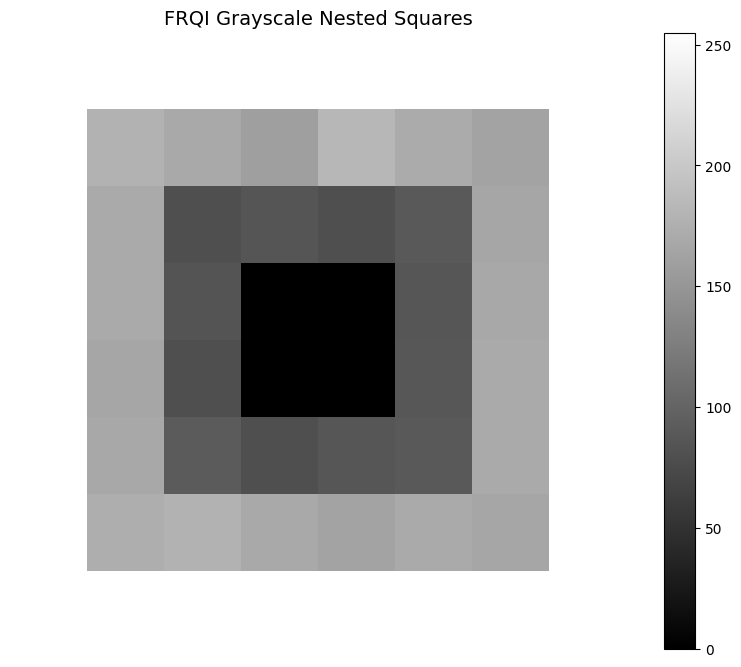

In [124]:
R, C = 8, 8
max_layer = min(R, C) // 2 - 1

grayscale_nested_squares = np.array([
    [255 - int(255 * min(y, x, R-1-y, C-1-x) / max_layer) for x in range(C)]
    for y in range(R)
], dtype=np.uint8)

print("Target grayscale nested squares:")
print(grayscale_nested_squares)
img_utils.display_image(grayscale_nested_squares, "Target Grayscale Nested Squares")

frqi_circuit, n_pos = encode_frqi_grayscale(grayscale_nested_squares)
frqi_circuit.measure_all()

num_shots = 400 * (2**n_pos)
counts = q_utils.run_simulation(frqi_circuit, shots=num_shots)

reconstructed = reconstruct_grayscale_from_frqi(
    counts,
    n_pos,
    grayscale_nested_squares.shape
)

print(f"\n{'='*60}")
print("Reconstructed grayscale nested squares:")
print(reconstructed)

img_utils.display_image(reconstructed, "FRQI Grayscale Nested Squares")

## Pattern 7 - Quantum Sierpiński Triangle (Bonus)
This challenge consists of building **a single FRQI circuit** that allows you to reconstruct:
- the **normal** image;
- the **inverted** image.

![Sierpiński triangle](images/fractal.png)

The idea is that after taking **many measurements**, you obtain **two groups of results** depending on the value of a **selection qubit**, and then you reconstruct one image per group.

The **classical mask** necessary to build the fractal is given below.

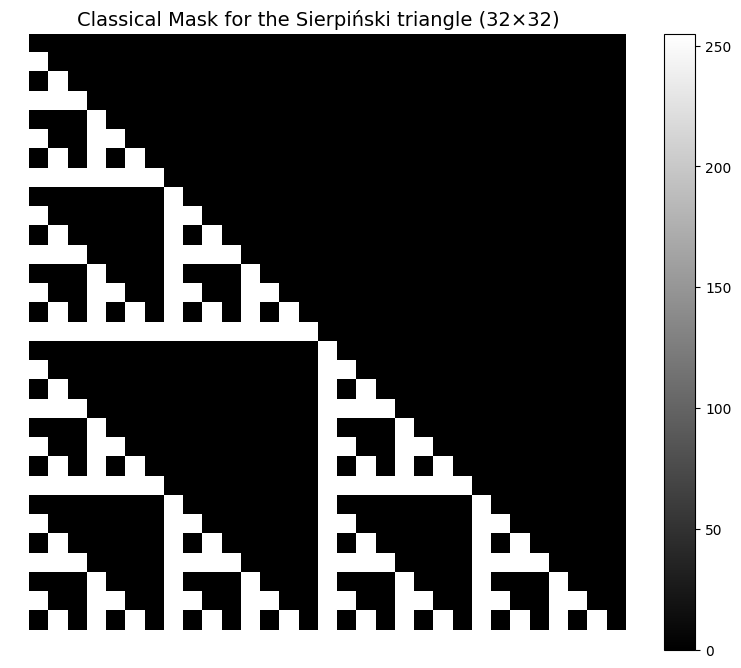

In [125]:
def sierpinski_triangle_mask(size=32):
    """Return a binary mask (size x size) for the Sierpiński triangle."""
    mask = np.zeros((size, size), dtype=int)
    for row in range(size):
        for col in range(size):
            if col <= row and (row & col) == col:
                mask[row, col] = 1
    return mask


size = 32
mask = sierpinski_triangle_mask(size)
display_image(mask * 255, f"Classical Mask for the Sierpiński triangle ({size}×{size})", cmap='gray')

In [126]:
# todo